In [1]:
import os
import sys
sys.path.append('../')
import numpy as np
import matplotlib.pyplot as plt

from models.ModelConfig import ModelConfig
import engine.utils.plot_utils as plot_utils
import engine.utils.test_utils as test_utils

# from pydose_rt.engine.data import DataGenerator  # Your converted PyTorch DataGenerator
from pydose_rt.engine.data_augment import DataGenerator  # Your converted PyTorch DataGenerator
from torch.utils.data import DataLoader  # PyTorch DataLoader

# Optional: import torchio only if user passes transform; safe to import here
import torchio as tio

/home/rd/anaconda3/envs/autoplan/lib/python3.11/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
/home/rd/anaconda3/envs/autoplan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
notebook_dir = os.getcwd()
parent_dir = os.path.dirname(notebook_dir)

In [8]:
gen_dataset = DataGenerator(
    os.path.join(parent_dir, "database/AUTORPT/"),
    "training",
    shuffle=False,
    batch_size=1,
    is_return_file_name=True,
    downsampling_factor=2,
    # downsampling_factor=1,
    is_debug=0,
    verbose=1,
)
# Use DataLoader to create iterable batches
train_loader = DataLoader(
    gen_dataset,
    batch_size=1,
    shuffle=False,  # Important for training, tells DataLoader to call dataset.on_epoch_end()
    num_workers=0,  # Adjust based on your CPU cores; 0 for main process
    pin_memory=True,  # For faster GPU data transfer
)

Number of files: 1092 in training cohort


In [9]:
def plot(train_loader, is_show_ct=False):
    for i, batch_data in enumerate(train_loader):
        # Unpack batch
        x, y_dose, masks, region_weights, constraints_batch, file_name = batch_data
        if i == 0:
            break

    # Extract CT (channel 0)
    ct = x[0, 0].cpu().numpy()  # (D, H, W)

    # Extract all 7 masks
    masks_np = masks[0].cpu().numpy()  # (7, D, H, W)

    # Define labels
    mask_labels = ["PTV", "ROI1", "ROI2", "ROI3", "ROI4", "ROI5", "ROI6"]

    slice_idx = int(ct.shape[-1] / 2)  # middle slice along last axis


    if is_show_ct:
        plt.imshow(ct[:, :, slice_idx], cmap="gray")
        plt.tight_layout()
        plt.show()

    # Make figure: CT + 7 masks
    n_cols = len(mask_labels) + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 4))

    # --- Plot the CT scan ---
    axes[0].imshow(ct[:, :, slice_idx], cmap="gray")
    axes[0].set_title("CT Scan")
    axes[0].axis("off")

    # --- Plot each mask ---
    for j, label in enumerate(mask_labels, start=1):
        axes[j].imshow(masks_np[j - 1, :, :, slice_idx], cmap="gray")
        axes[j].set_title(label)
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
  

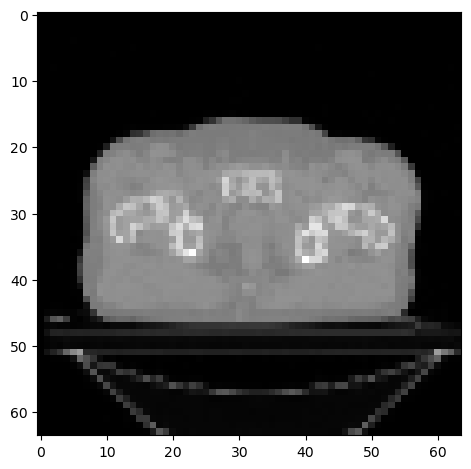

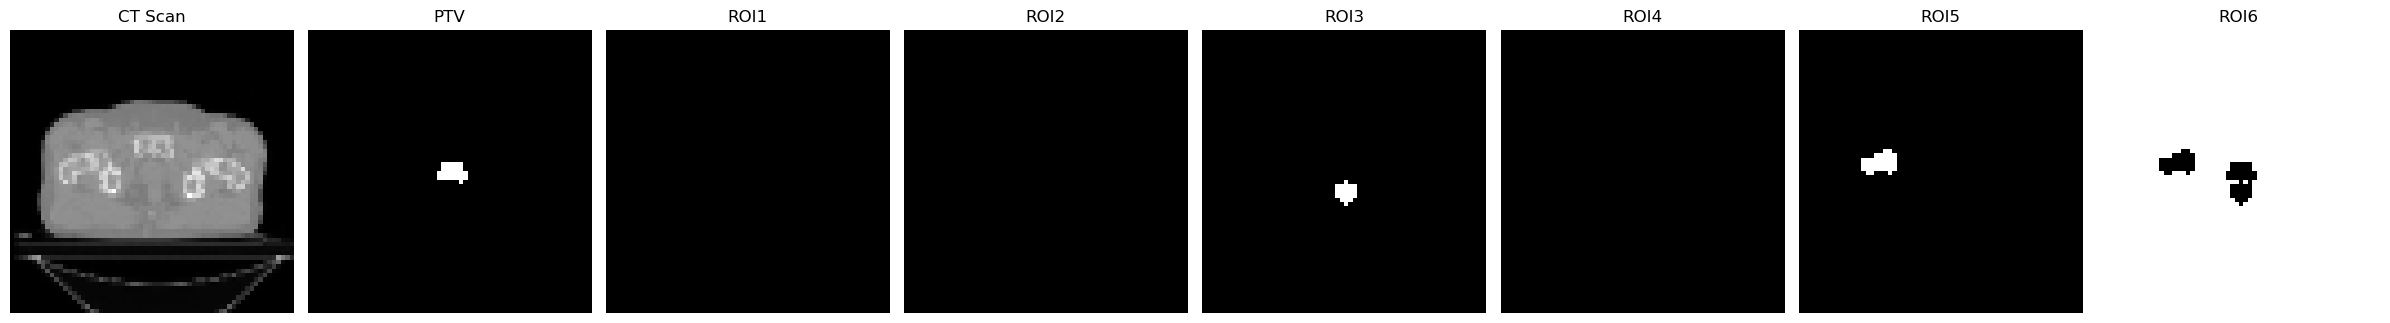

In [10]:
plot(train_loader, is_show_ct=True)

In [6]:
gen_dataset = DataGenerator(
    os.path.join(parent_dir, "database/AUTORPT/"),
    "training",
    shuffle=False,
    batch_size=1,
    is_return_file_name=True,
    transform=tio.Compose([
        tio.RandomFlip(axes=(1,), flip_probability=0.5),  # left-right flip
        tio.RandomAffine(
            scales=(0.75, 1.25),                          # zoom in/out 15–25%
            degrees=(10, 10, 10),                         # small rotations
            translation=(0.1, 0.2),                       # 10–20% shift along each axis
            center='image',                               # use image center
        ),
    ]),
    downsampling_factor=1,
    is_debug=0,
    verbose=1,
)
# Use DataLoader to create iterable batches
train_loader = DataLoader(
    gen_dataset,
    batch_size=1,
    shuffle=False,  # Important for training, tells DataLoader to call dataset.on_epoch_end()
    num_workers=0,  # Adjust based on your CPU cores; 0 for main process
    pin_memory=True,  # For faster GPU data transfer
)

Number of files: 1092 in training cohort


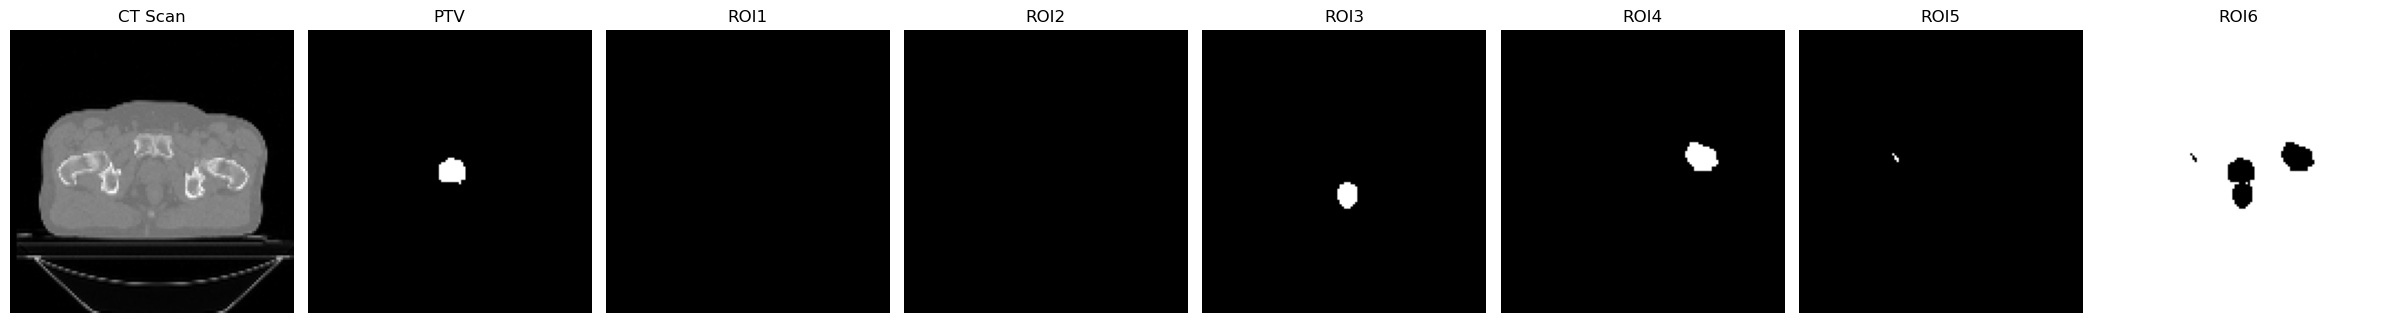

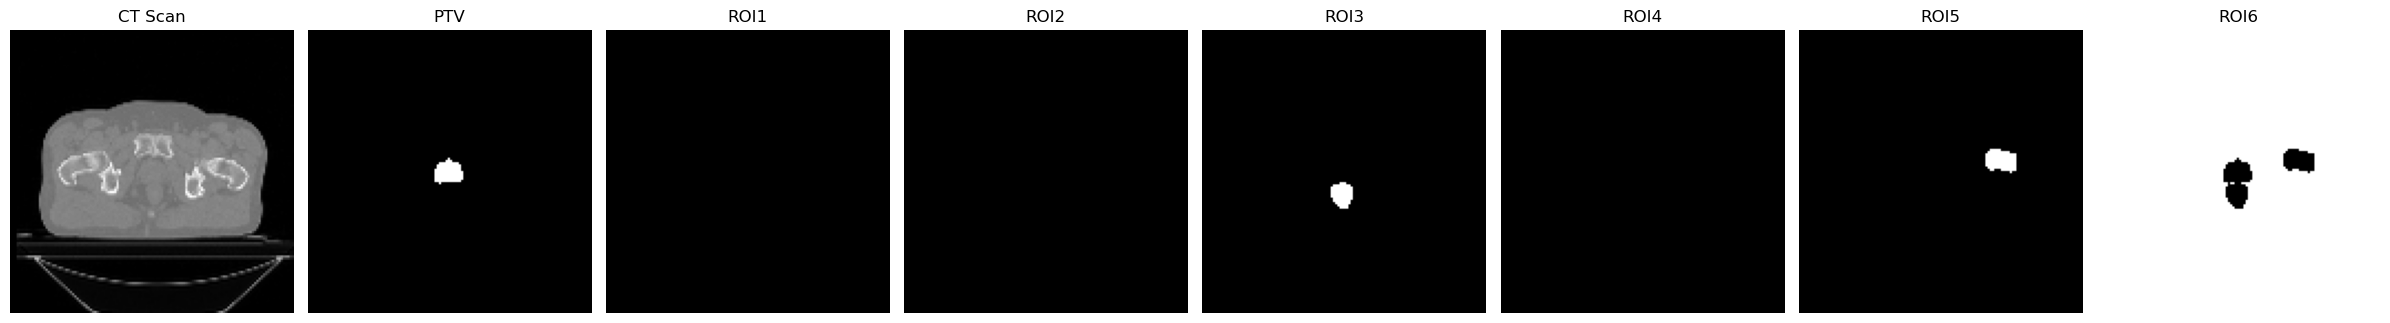

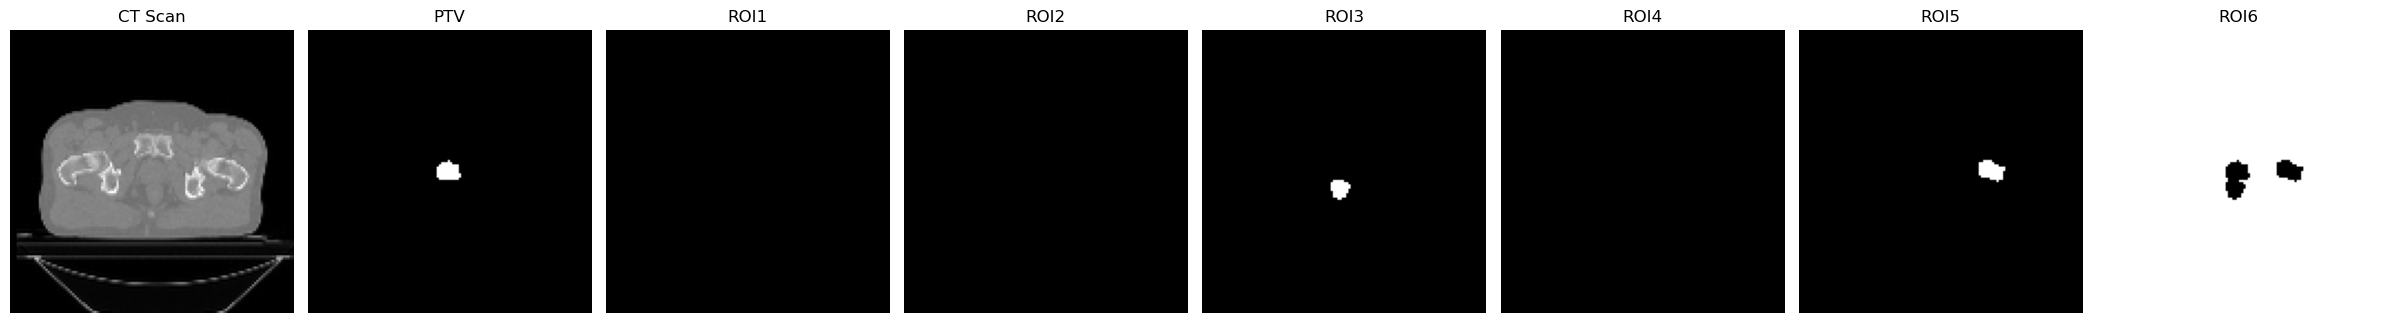

In [7]:
plot(train_loader)
plot(train_loader)
plot(train_loader)
# plot(train_loader)
# plot(train_loader)
# plot(train_loader)
# plot(train_loader)
# plot(train_loader)
# plot(train_loader)
# plot(train_loader)
# plot(train_loader)
# plot(train_loader)